In [1]:
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

In [2]:
class KMeansClustering:
    def __init__(self, n_clusters=8, max_iter=300, tol=0.0001, random_state=0):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def _greedy_kmeans_plus_plus(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        n_local_trials = 2 + int(np.log(self.n_clusters))

        indices = np.arange(n_samples)
        first_index = np.random.choice(indices)
        centers = np.zeros((self.n_clusters, n_features))

        centers[0] = X[first_index]
        first_center = centers[0].reshape(1, -1)
        sq_distances = cdist(X, first_center, metric='sqeuclidean').ravel()

        for i in range(1, self.n_clusters):
            min_cost = np.inf
            min_new_sq_distances = []
            best_candidate_index = None

            for _ in range(n_local_trials):
                candidates_probas = sq_distances / np.sum(sq_distances)
                candidate_index = np.random.choice(indices, p=candidates_probas)
                candidate = X[candidate_index].reshape(1, -1)

                new_sq_distances = cdist(X, candidate, metric='sqeuclidean').ravel()
                new_cost = np.sum(np.minimum(sq_distances, new_sq_distances))

                if new_cost < min_cost:
                    best_candidate_index = candidate_index
                    min_new_sq_distances = new_sq_distances
                    min_cost = new_cost

            centers[i] = X[best_candidate_index]   # Choose the new center
            sq_distances = np.minimum(sq_distances, min_new_sq_distances)

        return centers

    def fit(self, X):
        n_samples, n_features = X.shape
        self.inertia_ = np.inf
        self.cluster_centers_ = self._greedy_kmeans_plus_plus(X)

        # Lloyd's algorithm
        for _ in range(self.max_iter):
            distances = cdist(X, self.cluster_centers_, metric='sqeuclidean')
            labels = np.argmin(distances, axis=1)
            new_inertia = np.sum(np.min(distances, axis=1))
            new_centers = np.zeros((self.n_clusters, n_features))

            for k in range(self.n_clusters):
                new_centers[k] = np.mean(X[labels == k], axis=0)

            if np.abs(new_inertia - self.inertia_) < self.tol:
                break

            self.inertia_ = new_inertia
            self.cluster_centers_ = new_centers

    def predict(self, X):
        distances = cdist(X, self.cluster_centers_, metric='sqeuclidean')
        predicted_labels = np.argmin(distances, axis=1)

        return predicted_labels

In [3]:
X, y = make_blobs(n_samples=250, n_features=2, centers=8, random_state=0)
print(y)

[1 3 7 7 6 7 1 3 7 7 0 3 1 1 3 3 5 1 7 4 0 1 1 3 4 7 0 0 6 7 0 0 5 5 7 2 1
 1 6 5 4 7 1 2 1 1 4 3 6 4 7 3 0 2 2 1 7 2 4 0 0 0 1 4 6 5 0 4 6 6 4 4 1 4
 2 3 1 1 5 4 6 4 1 2 5 0 7 6 7 3 0 1 2 5 1 5 3 3 3 1 5 4 0 4 7 6 2 2 2 4 6
 2 5 1 6 4 0 6 5 0 0 6 3 5 1 6 0 2 5 5 6 3 3 1 5 4 5 0 2 2 3 0 4 7 5 4 2 0
 2 6 2 5 2 1 4 1 5 0 4 6 7 5 5 7 6 2 2 3 6 1 7 3 4 7 2 6 6 4 2 2 0 5 4 4 6
 3 1 7 6 7 7 0 4 5 7 2 6 6 2 5 3 3 2 7 1 7 6 6 4 3 5 7 6 3 5 0 3 3 5 5 2 0
 6 3 4 0 5 3 5 2 0 6 4 0 1 1 2 2 0 1 3 7 0 7 0 3 4 7 3 7]


In [4]:
kmeans = KMeansClustering(n_clusters=8, random_state=42)
kmeans.fit(X)
kmeans_pred_res = kmeans.predict(X)
kmeans_ari = adjusted_rand_score(y, kmeans_pred_res)
kmeans_centroinds = kmeans.cluster_centers_
print(f'Adjusted Rand Score for KMeans: {kmeans_ari}', '', sep='\n')
print('centroids', kmeans_centroinds, '', sep='\n')
print('prediction', kmeans_pred_res, sep='\n')

Adjusted Rand Score for KMeans: 0.8039378981613242

centroids
[[ 0.97744533  4.14452394]
 [-8.61527648 -8.32916569]
 [ 9.20217726 -2.23709633]
 [-1.5438023   7.64224793]
 [ 2.3666746   1.30457024]
 [-1.57870759  2.93158628]
 [ 1.47433518  8.49698324]
 [ 5.86512606  0.19818122]]

prediction
[4 3 1 1 6 1 4 3 1 1 4 3 4 4 3 3 4 4 1 2 0 7 0 3 2 1 0 0 6 1 3 0 7 7 1 5 4
 4 6 7 2 1 4 5 4 4 2 3 6 7 1 3 0 0 5 4 1 5 2 0 0 5 4 2 6 7 0 2 6 6 2 2 4 2
 5 3 4 4 7 2 0 2 4 5 7 0 1 6 1 6 5 4 5 4 4 7 3 3 3 0 7 2 0 2 1 6 5 5 5 2 6
 5 7 4 3 2 0 6 7 0 5 6 3 7 4 6 0 5 7 7 6 3 3 4 7 2 7 0 5 5 3 0 2 1 7 2 5 0
 5 6 5 7 5 4 2 4 7 0 2 6 1 7 4 1 6 5 0 0 6 4 1 3 2 1 5 6 6 2 5 5 0 7 2 2 6
 3 4 1 6 1 1 0 2 7 1 5 6 6 5 7 3 3 5 1 4 1 6 3 2 3 4 1 6 6 7 0 3 3 7 7 5 0
 6 3 2 0 7 3 7 5 5 6 2 0 4 4 5 5 0 0 3 1 0 1 0 3 2 1 3 1]


Text(0, 0.5, 'Feature 2')

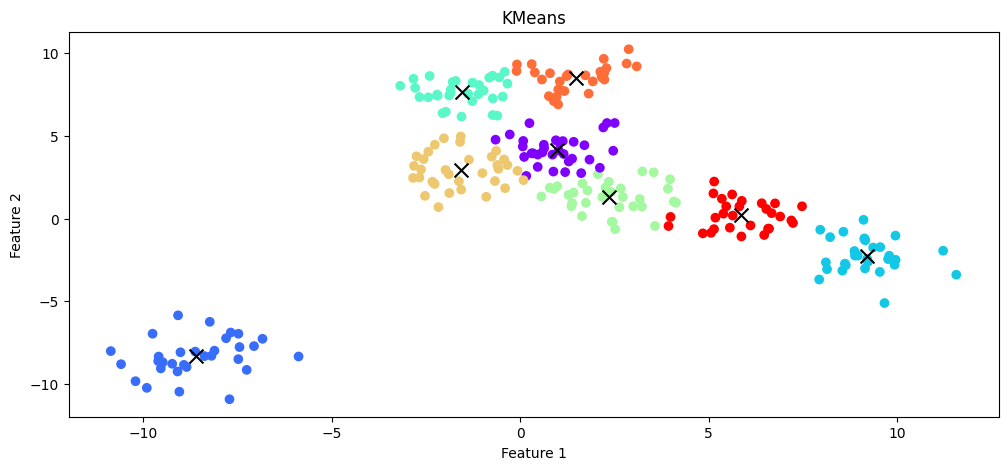

In [7]:
plt.figure(figsize=(12, 5))


plt.subplots_adjust(wspace=0.2)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_pred_res, cmap="rainbow")
plt.scatter(kmeans_centroinds[:, 0], kmeans_centroinds[:, 1], marker="x", color="black", s=100)
plt.title("KMeans")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

